In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from astropy.io import fits


In [2]:
star_path = "../../data/spec-0323-51615-0616.fits"

Inspecting the fits file

In [3]:
with fits.open(star_path) as star_data:
    star_data.info()

Filename: ../../data/spec-0323-51615-0616.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     124   ()      
  1  COADD         1 BinTableHDU     26   3823R x 8C   [E, E, E, J, J, E, E, E]   
  2  SPECOBJ       1 BinTableHDU    262   1R x 126C   [6A, 4A, 16A, 23A, 16A, 8A, E, E, E, J, E, E, J, B, B, B, B, B, B, J, 22A, 19A, 19A, 22A, 19A, I, 3A, 3A, 1A, J, D, D, D, E, E, 19A, 8A, J, J, J, J, K, K, J, J, J, J, J, J, K, K, K, K, I, J, J, J, J, 5J, D, D, 6A, 21A, E, E, E, J, E, 24A, 10J, J, 10E, E, E, E, E, E, E, J, E, E, E, J, E, 5E, E, 10E, 10E, 10E, 5E, 5E, 5E, 5E, 5E, J, J, E, E, E, E, E, E, 25A, 21A, 10A, E, E, E, E, E, E, E, E, J, E, E, J, 1A, 1A, E, E, J, J, 1A, 5E, 5E]   
  3  SPZLINE       1 BinTableHDU     48   29R x 19C   [J, J, J, 13A, D, E, E, E, E, E, E, E, E, E, E, J, J, E, E]   


In [4]:
primary = star_data[0].header

In [5]:
for key in primary:
    print(key)


SIMPLE
BITPIX
NAXIS
EXTEND
TAI
RA
DEC
EQUINOX
RADECSYS
TAIHMS
TIMESYS
MJD
MJDLIST
VERSION
CAMVER
OBSERVER
TELESCOP
BESTEXP
NEXP_B1
NEXP_R1
EXPT_B1
EXPT_R1
EXPTIME
SPCOADD
FLAVOR
QUALITY
RADEG
DECDEG
PLATEID
TILEID
CARTID
MAPID
NAME
COLBIN
ROWBIN
PROGRAM
SECFOCUS
GUIDEIMG
WTIME
AIRTEMP
DEWPOINT
DEWDEP
DUSTA
DUSTB
DUSTC
DUSTD
GUSTD
GUSTS
HUMIDITY
HUMIDOUT
PRESSURE
WINDD
WINDS
VERSIDL
VERSUTIL
VERSREAD
VERS2D
VERSCOMB
VERSLOG
VERSFLAT
OPBC
OPCONFIG
OPECALIB
PLUGFILE
HELIO_RV
VACUUM
SFLATTEN
PSFSKY
SKYCHI2
SCHI2MIN
SCHI2MAX
PREJECT
SPEC1_G
SPEC1_R
SPEC1_I
SPEC2_G
SPEC2_R
SPEC2_I
NSTD
GOFFSTD
GRMSSTD
ROFFSTD
RRMSSTD
IOFFSTD
IRMSSTD
GROFFSTD
GRRMSSTD
RIOFFSTD
RIRMSSTD
LOWREJ
HIGHREJ
SCATPOLY
PROFTYPE
NFITPOLY
XCHI2
XCHI2MIN
XCHI2MAX
SHIFTGUE
SHIFT
SHIFTERR
NWORDER
WFITTYPE
COEFF0
COEFF1
FBADPIX
FBADPIX1
FBADPIX2
WAT0_001
WAT1_001
DC-FLAG
BUNIT
PLUG_RA
PLUG_DEC
SPEC_ID
FIBERID
NEXP
EXPID01
EXPID02
EXPID03
EXPID04
EXPID05
EXPID06
EXPID07
EXPID08


In [6]:
secondary = star_data[1].header
secondary

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   32 / length of dimension 1                          
NAXIS2  =                 3823 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    8 / number of table fields                         
TTYPE1  = 'flux    '                                                            
TFORM1  = 'E       '                                                            
TTYPE2  = 'loglam  '                                                            
TFORM2  = 'E       '                                                            
TTYPE3  = 'ivar    '        

In [7]:
with fits.open(star_path) as star_data:
    secondary_data = star_data[1].data
    print(secondary_data)
    print(secondary_data.shape)

    flux = secondary_data["flux"]
    wavelength = 10 ** secondary_data["loglam"]   # since wavelength is in log base 10 form
    print(flux)
    print(flux.shape)
    print(wavelength)
    print(wavelength.shape)

[(12.635661 , 3.5814, 0.15848312, 0, 0, 0.9931843 ,  8.744145 , 12.3484535)
 ( 8.32157  , 3.5815, 0.16710302, 0, 0, 0.9930663 ,  9.52261  , 12.023306 )
 ( 5.8833814, 3.5816, 0.17576131, 0, 0, 0.99294823, 10.282889 , 11.512757 )
 ...
 (18.95889  , 3.9634, 0.8938005 , 0, 0, 0.644431  ,  2.5208137, 19.645447 )
 (19.968723 , 3.9635, 0.827907  , 0, 0, 0.6442609 ,  2.4689279, 19.759197 )
 (18.921745 , 3.9636, 0.76013786, 0, 0, 0.6440906 ,  2.5254512, 19.92751  )]
(3823,)
[12.635661   8.32157    5.8833814 ... 18.95889   19.968723  18.921745 ]
(3823,)
[3814.169  3815.0483 3815.926  ... 9191.786  9193.905  9196.0205]
(3823,)


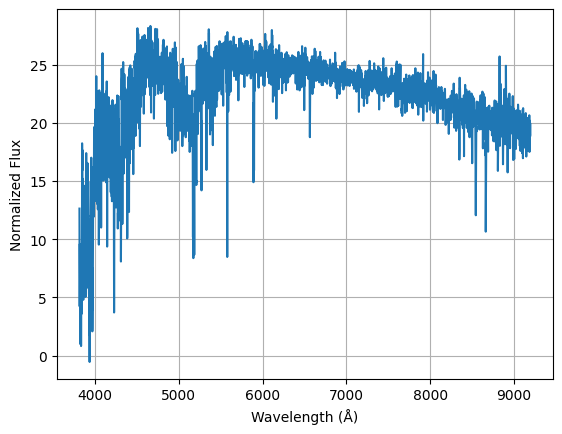

In [8]:
plt.plot(wavelength, flux)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.grid()

### Inspecting the spectra files for SDSS

In [9]:
import os

In [10]:
spectra_files = os.listdir("/home/arbiter/projects/Survey-invariant-generalization/data") 

for i in spectra_files:
    if ".fits" in i:
        spectra_files.remove(i)

spectra_files

['spectra_F.npy',
 'spectra_A.npy',
 'spectra_O.npy',
 'spectra_K.npy',
 'spectra_B.npy',
 'spectra_M.npy',
 'spectra_G.npy',
 'spec-0323-51615-0616.fits']

In [11]:
total_data = 0
for i in spectra_files:
    
    spectra = np.load(f"../../data/{i}", allow_pickle= True)
    spec_len = len(spectra)
    total_data += spec_len

print(f"Datapoints : {total_data}")
    

UnpicklingError: Failed to interpret file '../../data/spec-0323-51615-0616.fits' as a pickle

In [13]:
spectra = np.load("../../data/spectra_A.npy", allow_pickle= True)
len(spectra[0]) - 1

3833

### Checking for redshifts in the spectral data